# Discriminator Evaluation — NPR & CommFor

Evaluates **ALL** images in configurable directories with two SOTA deepfake detectors:

1. **NPR** (CVPR 2024) — Neighboring Pixel Relationships, truncated ResNet50 (~6M params)
2. **CommFor** (CVPR 2025) — Community Forensics, ViT-Small trained on 4,803 generators

Results are merged by filename into existing CSVs that contain CLIP model predictions.

**Configurations** (6 total):
- Raw Input, SDXL Inpainted, Kandinsky Inpainted (1,000 images each)
- Raw Input PRNU, SDXL Inpainted PRNU, Kandinsky Inpainted PRNU (3,000 images each — 3 PRNU injection variants)

**Metrics** (threshold = 0.5, all images are fake):
- **Detection Rate (Accuracy)**: % of fake images correctly detected as fake
- **ASR (Attack Success Rate)**: % of images correctly detected in baseline that evade detection after inpainting (paired per-image; PRNU configs pair within same PRNU variant)
- **Confidence Reduction**: mean drop in fakeness score after inpainting (positive = less confident fake)

## 1. Setup

In [30]:
import io
import os
import re
import tarfile
from math import ceil
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Configuration

Update all placeholder paths below to match your Google Drive layout.

In [31]:
# === IMAGE CONFIGURATIONS ===
# Each config: name, image_dir(s), csv_path (existing CLIP results), ground truth label.
# Use "image_dir" for a single directory, or "image_dirs" for multiple subdirectories.
# "baseline" (optional): name of the config to use as baseline for ASR computation.
CONFIGS = [
    # --- Non-PRNU configs ---
    {
        "name": "Raw Input",
        "csv_path": "impainting_input.csv",
        "label": "fake",
    },
    {
        "name": "SDXL Inpainted",
        "csv_path": "output_impainting_sdxl.csv",
        "label": "fake",
        "baseline": "Raw Input",
    },
    {
        "name": "Kandinsky Inpainted",
        "csv_path": "output_inpainting_kandinsky.csv",
        "label": "fake",
        "baseline": "Raw Input",
    },
    
    # --- PRNU Additive injected ---
    {
        "name": "Raw Input PRNU (Additive)",
        "csv_path": "output_raw_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input",
        "variant": "additive"
    },
    {
        "name": "SDXL Inpainted PRNU (Additive)",
        "csv_path": "output_impainting_sdxl_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU (Additive)",
        "variant": "additive"
    },
    {
        "name": "Kandinsky Inpainted PRNU (Additive)",
        "csv_path": "output_inpainting_kandinsky_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU (Additive)",
        "variant": "additive"
    },
    
    # --- PRNU Dynamic PSNR injected ---
    {
        "name": "Raw Input PRNU (Dynamic)",
        "csv_path": "output_raw_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input",
        "variant": "dynamic_psnr"
    },
    {
        "name": "SDXL Inpainted PRNU (Dynamic)",
        "csv_path": "output_impainting_sdxl_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU (Dynamic)",
        "variant": "dynamic_psnr"
    },
    {
        "name": "Kandinsky Inpainted PRNU (Dynamic)",
        "csv_path": "output_inpainting_kandinsky_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU (Dynamic)",
        "variant": "dynamic_psnr"
    },
    
    # --- PRNU Scaled Injected ---
    {
        "name": "Raw Input PRNU (Scaled)",
        "csv_path": "output_raw_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input",
        "variant": "scaled"
    },
    {
        "name": "SDXL Inpainted PRNU (Scaled)",
        "csv_path": "output_impainting_sdxl_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU (Scaled)",
        "variant": "scaled"
    },
    {
        "name": "Kandinsky Inpainted PRNU (Scaled)",
        "csv_path": "output_inpainting_kandinsky_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU (Scaled)",
        "variant": "scaled"
    },
    
    # --- PRNU-injected configs (Combined) ---
    {
        "name": "Raw Input PRNU",
        "csv_path": "output_raw_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input",
    },
    {
        "name": "SDXL Inpainted PRNU",
        "csv_path": "output_impainting_sdxl_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU",
    },
    {
        "name": "Kandinsky Inpainted PRNU",
        "csv_path": "output_inpainting_kandinsky_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU",
    },
]

print(f"Configurations: {len(CONFIGS)}")

Configurations: 15


## Load CSV's

In [ ]:
MODELS = {
    "CLIP": "CLIP_label_prediction",
    "NPR": "NPR_label_prediction",
    "CommFor": "CommFor_label_prediction",
}

PRNU_VARIANTS = ['additive', 'dynamic_psnr', 'scaled']

# === HELPER FUNCTIONS ===
def strip_to_base_name(filename):
    """Strips spoofing and inpainting tags to match images across baselines."""
    s = str(filename)
    s = re.sub(r'_spoofed_by_D\d+_[^.]+', '', s)
    s = re.sub(r'_out_[^.]+', '', s)
    return s.lower()

def extract_prnu_variant(path):
    path_str = str(path)
    for variant in PRNU_VARIANTS:
        if f'prnu_injected_{variant}' in path_str:
            return variant
    return 'none'

def compute_detection_rate(df, label_col):
    """Returns % of fake images predicted as fake (0)."""
    valid = df[label_col].dropna()
    if len(valid) == 0:
        return None
    return (valid == 0).sum() / len(valid)

def compute_asr(baseline_df, inpainted_df, label_col, use_prnu_variant=False):
    """Compute Attack Success Rate (paired per-image).

    ASR = (correctly detected in baseline AND misclassified after inpainting) /
          (correctly detected in baseline)

    For PRNU configs, matches on (base_name, prnu_variant) to ensure
    additive pairs with additive, etc.
    """
    raw = baseline_df[["file_name", label_col]].copy()
    raw["base_name"] = raw["file_name"].map(strip_to_base_name)

    inp = inpainted_df[["file_name", label_col]].copy()
    inp["base_name"] = inp["file_name"].map(strip_to_base_name)

    if use_prnu_variant and "path" in baseline_df.columns and "path" in inpainted_df.columns:
        raw["prnu_variant"] = baseline_df["path"].map(extract_prnu_variant)
        inp["prnu_variant"] = inpainted_df["path"].map(extract_prnu_variant)
        merge_keys = ["base_name", "prnu_variant"]
    else:
        merge_keys = ["base_name"]

    merged = raw[merge_keys + [label_col]].merge(
        inp[merge_keys + [label_col]],
        on=merge_keys, suffixes=("_raw", "_inp")
    )
    raw_col = f"{label_col}_raw"
    inp_col = f"{label_col}_inp"

    merged = merged.dropna(subset=[raw_col, inp_col])

    caught_raw = merged[merged[raw_col] == 0]
    if len(caught_raw) == 0:
        return None, 0, 0, len(merged)

    evaded = (caught_raw[inp_col] == 1).sum()
    asr = evaded / len(caught_raw)
    return asr, int(evaded), len(caught_raw), len(merged)



# === DATA PIPELINE ===
print("Processing CSV Data...")
merged_dfs = {}

for config in CONFIGS:
    name = config["name"]
    csv_path = config["csv_path"]
    variant = config.get("variant")

    # Load the CSV
    try:
        df = pd.read_csv(csv_path, encoding="utf-8-sig")
    except FileNotFoundError:
        print(f"ERROR: Could not find CSV at {csv_path}")
        continue

    # ── The Forensic Filter ──
    # If the config specifies a variant, isolate those rows
    if variant:
        df = df[df["path"].str.contains(variant, na=False)].copy()

    # We assume the CSVs already contain NPR and CommFor scores.
    # Store the filtered DataFrame.
    merged_dfs[name] = df

print(f"Successfully loaded {len(merged_dfs)} configurations.\n")

summary_rows = []
baselines_shown = set()

Processing CSV Data...
Successfully loaded 15 configurations.



## Baseline Metrics

In [33]:
for config in CONFIGS:
    baseline_name = config.get("baseline")
    if baseline_name and baseline_name not in baselines_shown and baseline_name in merged_dfs:
        baselines_shown.add(baseline_name)
        print(f"\n{'='*60}")
        print(f"Baseline Detection Rates — {baseline_name}")
        print(f"{'='*60}")
        bdf = merged_dfs[baseline_name]
        for model_name, label_col in MODELS.items():
            if label_col not in bdf.columns:
                continue
            dr = compute_detection_rate(bdf, label_col)
            if dr is not None:
                n_detected = int(dr * bdf[label_col].notna().sum())
                print(f"  {model_name}: {dr*100:.2f}% ({n_detected}/{bdf[label_col].notna().sum()})")


Baseline Detection Rates — Raw Input
  CLIP: 88.70% (887/1000)
  NPR: 92.30% (923/1000)
  CommFor: 90.60% (906/1000)

Baseline Detection Rates — Raw Input PRNU (Additive)
  CLIP: 85.40% (854/1000)
  NPR: 90.20% (902/1000)
  CommFor: 88.10% (881/1000)

Baseline Detection Rates — Raw Input PRNU (Dynamic)
  CLIP: 87.80% (878/1000)
  NPR: 87.30% (873/1000)
  CommFor: 86.10% (861/1000)

Baseline Detection Rates — Raw Input PRNU (Scaled)
  CLIP: 86.00% (860/1000)
  NPR: 61.30% (613/1000)
  CommFor: 68.90% (689/1000)

Baseline Detection Rates — Raw Input PRNU
  CLIP: 86.40% (2592/3000)
  NPR: 79.60% (2388/3000)
  CommFor: 81.03% (2431/3000)


## Relative Attack Success Rate (ASR)

In [34]:
for config in CONFIGS:
    name = config["name"]
    if name not in merged_dfs: continue
    df = merged_dfs[name]
    baseline_name = config.get("baseline")

    print(f"\n{'='*60}")
    print(f"{name} (n={len(df)})")
    print(f"{'='*60}")

    rows = []
    for model_name, label_col in MODELS.items():
        if label_col not in df.columns: continue

        det_rate = compute_detection_rate(df, label_col)
        asr = None
        n_paired, evaded, caught = 0, 0, 0

        if baseline_name and baseline_name in merged_dfs:
            is_prnu = "PRNU" in name
            asr_val, evaded, caught, n_paired = compute_asr(
                merged_dfs[baseline_name], df, label_col, use_prnu_variant=is_prnu
            )
            asr = asr_val

        row = {"Model": model_name, "n": len(df), "Detection Rate": det_rate, "ASR": asr}
        rows.append(row)
        summary_rows.append({"Config": name, **row})

        if baseline_name and n_paired > 0:
            print(f"  {model_name}: Paired={n_paired} | Caught Raw={caught} | Evaded Inp={evaded}")

    # Display per-config table
    display_df = pd.DataFrame(rows).set_index("Model")
    display_df["Detection Rate"] = display_df["Detection Rate"].map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A")
    display_df["ASR"] = display_df["ASR"].map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "—")
    print(display_df.to_string())

print(f"\n\n{'='*60}")
print("GLOBAL SUMMARY — Attack Success Rate (ASR)")
print(f"{'='*60}")
asr_rows = [r for r in summary_rows if r["ASR"] is not None]
if asr_rows:
    asr_df = pd.DataFrame(asr_rows)
    pivot_asr = asr_df.pivot_table(index="Model", columns="Config", values="ASR", aggfunc="first")
    display_asr = pivot_asr.map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A")
    print(display_asr.to_string())


Raw Input (n=1000)
            n Detection Rate ASR
Model                           
CLIP     1000         88.70%   —
NPR      1000         92.30%   —
CommFor  1000         90.60%   —

SDXL Inpainted (n=1000)
  CLIP: Paired=1000 | Caught Raw=887 | Evaded Inp=30
  NPR: Paired=1000 | Caught Raw=923 | Evaded Inp=0
  CommFor: Paired=1000 | Caught Raw=906 | Evaded Inp=5
            n Detection Rate    ASR
Model                              
CLIP     1000         87.60%  3.38%
NPR      1000        100.00%  0.00%
CommFor  1000         97.10%  0.55%

Kandinsky Inpainted (n=1000)
  CLIP: Paired=1000 | Caught Raw=887 | Evaded Inp=29
  NPR: Paired=1000 | Caught Raw=923 | Evaded Inp=3
  CommFor: Paired=1000 | Caught Raw=906 | Evaded Inp=7
            n Detection Rate    ASR
Model                              
CLIP     1000         89.40%  3.27%
NPR      1000         99.60%  0.33%
CommFor  1000         98.20%  0.77%

Raw Input PRNU (Additive) (n=1000)
            n Detection Rate ASR
Model        

## Absolute ASR

In [35]:
# 2. Absolute Attack Success Rates
for config in CONFIGS:
    name = config["name"]
    if name not in merged_dfs: continue
    df = merged_dfs[name]
    
    # Check if this config is supposed to be an attack (has a baseline field at all)
    is_attack = "baseline" in config
    # FORCING THE ABSOLUTE BASELINE
    absolute_baseline = "Raw Input" 

    print(f"\n{'='*60}")
    print(f"{name} (n={len(df)})")
    print(f"{'='*60}")

    rows = []
    for model_name, label_col in MODELS.items():
        if label_col not in df.columns: continue

        det_rate = compute_detection_rate(df, label_col)
        asr = None
        n_paired, evaded, caught = 0, 0, 0

        # Only compute ASR if this is an attack config and the raw input exists
        if is_attack and absolute_baseline in merged_dfs:
            # CRITICAL FIX: use_prnu_variant MUST be False. 
            # We are comparing against clean images that have no variant.
            asr_val, evaded, caught, n_paired = compute_asr(
                merged_dfs[absolute_baseline], df, label_col, use_prnu_variant=False
            )
            asr = asr_val

        row = {"Model": model_name, "n": len(df), "Detection Rate": det_rate, "ASR": asr}
        rows.append(row)
        summary_rows.append({"Config": name, **row})

        if is_attack and n_paired > 0:
            print(f"  {model_name}: Paired={n_paired} | Caught Raw={caught} | Evaded Inp={evaded}")

    # Display per-config table
    display_df = pd.DataFrame(rows).set_index("Model")
    display_df["Detection Rate"] = display_df["Detection Rate"].map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A")
    display_df["ASR"] = display_df["ASR"].map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "—")
    print(display_df.to_string())

print(f"\n\n{'='*60}")
print("GLOBAL SUMMARY — ABSOLUTE Attack Success Rate (vs Clean Raw Input)")
print(f"{'='*60}")
asr_rows = [r for r in summary_rows if r["ASR"] is not None]
if asr_rows:
    asr_df = pd.DataFrame(asr_rows)
    pivot_asr = asr_df.pivot_table(index="Model", columns="Config", values="ASR", aggfunc="first")
    display_asr = pivot_asr.map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A")
    print(display_asr.to_string())


Raw Input (n=1000)
            n Detection Rate ASR
Model                           
CLIP     1000         88.70%   —
NPR      1000         92.30%   —
CommFor  1000         90.60%   —

SDXL Inpainted (n=1000)
  CLIP: Paired=1000 | Caught Raw=887 | Evaded Inp=30
  NPR: Paired=1000 | Caught Raw=923 | Evaded Inp=0
  CommFor: Paired=1000 | Caught Raw=906 | Evaded Inp=5
            n Detection Rate    ASR
Model                              
CLIP     1000         87.60%  3.38%
NPR      1000        100.00%  0.00%
CommFor  1000         97.10%  0.55%

Kandinsky Inpainted (n=1000)
  CLIP: Paired=1000 | Caught Raw=887 | Evaded Inp=29
  NPR: Paired=1000 | Caught Raw=923 | Evaded Inp=3
  CommFor: Paired=1000 | Caught Raw=906 | Evaded Inp=7
            n Detection Rate    ASR
Model                              
CLIP     1000         89.40%  3.27%
NPR      1000         99.60%  0.33%
CommFor  1000         98.20%  0.77%

Raw Input PRNU (Additive) (n=1000)
  CLIP: Paired=1000 | Caught Raw=887 | Evaded 

## Confidence Reduction

Measures how much each detector's confidence that an image is fake drops after inpainting.

**Per image**: `reduction = fakeness_raw - fakeness_inpainted`
- Positive = inpainting made the image look less fake
- Negative = inpainting made the image look more fake (detector is more confident)

In [39]:
CONF_COLS = {
    "CLIP": ("CLIP_label_prediction", "CLIP_confident_score"),
    "NPR": ("NPR_label_prediction", "NPR_confident_score"),
    "CommFor": ("CommFor_label_prediction", "CommFor_confident_score"),
}

def reconstruct_fakeness(df, label_col, conf_col):
    """Reconstruct raw fakeness score from (prediction, confident_score).

    If pred==0 (fake): fakeness = conf (score_to_prediction returned 0, score)
    If pred==1 (real): fakeness = 1 - conf (score_to_prediction returned 1, 1-score)
    """
    fakeness = df[conf_col].copy()
    real_mask = df[label_col] == 1
    fakeness[real_mask] = 1.0 - fakeness[real_mask]
    return fakeness

def compute_confidence_reduction(baseline_df, inpainted_df, label_col, conf_col,
                                  use_prnu_variant=False):
    """Compute per-image confidence reduction after inpainting.

    For PRNU configs, matches on (base_name, prnu_variant).
    """
    raw = baseline_df[["file_name", label_col, conf_col]].copy()
    raw["fakeness"] = reconstruct_fakeness(raw, label_col, conf_col)
    raw["base_name"] = raw["file_name"].map(strip_to_base_name)

    inp = inpainted_df[["file_name", label_col, conf_col]].copy()
    inp["fakeness"] = reconstruct_fakeness(inp, label_col, conf_col)
    inp["base_name"] = inp["file_name"].map(strip_to_base_name)

    if use_prnu_variant and "path" in baseline_df.columns and "path" in inpainted_df.columns:
        raw["prnu_variant"] = baseline_df["path"].map(extract_prnu_variant)
        inp["prnu_variant"] = inpainted_df["path"].map(extract_prnu_variant)
        merge_keys = ["base_name", "prnu_variant"]
    else:
        merge_keys = ["base_name"]

    merged = raw[merge_keys + ["fakeness"]].merge(
        inp[merge_keys + ["fakeness"]],
        on=merge_keys, suffixes=("_raw", "_inp")
    ).dropna()

    if len(merged) == 0:
        return None

    merged["reduction"] = merged["fakeness_raw"] - merged["fakeness_inp"]

    return {
        "n_paired": len(merged),
        "mean_reduction": merged["reduction"].mean(),
        "median_reduction": merged["reduction"].median(),
        "std_reduction": merged["reduction"].std(),
        "pct_reduced": (merged["reduction"] > 0).mean(),
        "mean_fakeness_raw": merged["fakeness_raw"].mean(),
        "mean_fakeness_inp": merged["fakeness_inp"].mean(),
    }

conf_reduction_rows = []

for config in CONFIGS:
    name = config["name"]
    baseline_name = config.get("baseline")

    if not baseline_name or baseline_name not in merged_dfs:
        continue

    print(f"\n--- Confidence Reduction: {name} vs {baseline_name} ---")

    is_prnu = "PRNU" in name
    use_variant_matching = is_prnu if baseline_name != "Raw Input" else False
    rows = []

    for model_name, (label_col, conf_col) in CONF_COLS.items():
        if label_col not in merged_dfs[name].columns:
            continue
            
        result = compute_confidence_reduction(
            merged_dfs[baseline_name], merged_dfs[name], label_col, conf_col,
            use_prnu_variant=use_variant_matching # <--- USE THE NEW VARIABLE
        )

        if result is None:
            print(f"  {model_name}: no paired images found")
            continue

        rows.append({
            "Model": model_name,
            "Mean Raw Fakeness": f"{result['mean_fakeness_raw']:.4f}",
            "Mean Inp Fakeness": f"{result['mean_fakeness_inp']:.4f}",
            "Mean Reduction": f"{result['mean_reduction']:+.4f}",
            "Median Reduction": f"{result['median_reduction']:+.4f}",
            "% Reduced": f"{result['pct_reduced']*100:.1f}%",
        })
        conf_reduction_rows.append({
            "Config": name, "Model": model_name, **result
        })

    if rows:
        print(pd.DataFrame(rows).set_index("Model").to_string())

if conf_reduction_rows:
    print(f"\n\n{'='*60}")
    print("GLOBAL SUMMARY — Mean Confidence Reduction (Positive = Less Confident Fake)")
    print(f"{'='*60}")
    cr_df = pd.DataFrame(conf_reduction_rows)
    pivot_cr = cr_df.pivot_table(
        index="Model", columns="Config", values="mean_reduction", aggfunc="first"
    )
    # Ensure columns are displayed in a clean format
    display_cr = pivot_cr.map(lambda x: f"{x:+.4f}" if pd.notna(x) else "N/A")
    print(display_cr.to_string())


--- Confidence Reduction: SDXL Inpainted vs Raw Input ---
        Mean Raw Fakeness Mean Inp Fakeness Mean Reduction Median Reduction % Reduced
Model                                                                                
CLIP               0.8570            0.8517        +0.0053          +0.0003     53.6%
NPR                0.9206            0.9992        -0.0786          +0.0000      1.4%
CommFor            0.9036            0.9667        -0.0631          +0.0000      9.9%

--- Confidence Reduction: Kandinsky Inpainted vs Raw Input ---
        Mean Raw Fakeness Mean Inp Fakeness Mean Reduction Median Reduction % Reduced
Model                                                                                
CLIP               0.8570            0.8669        -0.0099          -0.0003     44.4%
NPR                0.9206            0.9932        -0.0726          +0.0000      6.5%
CommFor            0.9036            0.9777        -0.0741          +0.0000     13.3%

--- Confidence R

## Absolute Confidence Reduction

In [40]:
# --- Absolute Confidence Reduction (vs Clean Raw Input) ---
abs_conf_reduction_rows = []
absolute_baseline = "Raw Input"

if absolute_baseline not in merged_dfs:
    print(f"CRITICAL ERROR: {absolute_baseline} not found in merged_dfs. Cannot compute Absolute ASR.")
else:
    for config in CONFIGS:
        name = config["name"]
        
        # We only compute reduction for "attacks" (things that have a baseline key)
        # We skip the Raw Input itself
        if "baseline" not in config or name == absolute_baseline:
            continue

        print(f"\n--- Absolute Confidence Reduction: {name} vs {absolute_baseline} ---")

        rows = []
        for model_name, (label_col, conf_col) in CONF_COLS.items():
            if label_col not in merged_dfs[name].columns:
                continue
            
            # CRITICAL: use_prnu_variant MUST be False 
            # because 'Raw Input' does not have variant strings in its paths.
            result = compute_confidence_reduction(
                merged_dfs[absolute_baseline], 
                merged_dfs[name], 
                label_col, 
                conf_col,
                use_prnu_variant=False 
            )

            if result is None:
                print(f"  {model_name}: no paired images found")
                continue

            rows.append({
                "Model": model_name,
                "Mean Raw Fakeness": f"{result['mean_fakeness_raw']:.4f}",
                "Mean Inp Fakeness": f"{result['mean_fakeness_inp']:.4f}",
                "Mean Reduction": f"{result['mean_reduction']:+.4f}",
                "Median Reduction": f"{result['median_reduction']:+.4f}",
                "% Reduced": f"{result['pct_reduced']*100:.1f}%",
            })
            abs_conf_reduction_rows.append({
                "Config": name, "Model": model_name, **result
            })

        if rows:
            print(pd.DataFrame(rows).set_index("Model").to_string())

# --- Global Summary: Absolute Confidence Reduction ---
if abs_conf_reduction_rows:
    print(f"\n\n{'='*60}")
    print("GLOBAL SUMMARY — Absolute Mean Confidence Reduction")
    print(f"{'='*60}")
    abs_cr_df = pd.DataFrame(abs_conf_reduction_rows)
    pivot_abs_cr = abs_cr_df.pivot_table(
        index="Model", columns="Config", values="mean_reduction", aggfunc="first"
    )
    display_abs_cr = pivot_abs_cr.map(lambda x: f"{x:+.4f}" if pd.notna(x) else "N/A")
    print(display_abs_cr.to_string())


--- Absolute Confidence Reduction: SDXL Inpainted vs Raw Input ---
        Mean Raw Fakeness Mean Inp Fakeness Mean Reduction Median Reduction % Reduced
Model                                                                                
CLIP               0.8570            0.8517        +0.0053          +0.0003     53.6%
NPR                0.9206            0.9992        -0.0786          +0.0000      1.4%
CommFor            0.9036            0.9667        -0.0631          +0.0000      9.9%

--- Absolute Confidence Reduction: Kandinsky Inpainted vs Raw Input ---
        Mean Raw Fakeness Mean Inp Fakeness Mean Reduction Median Reduction % Reduced
Model                                                                                
CLIP               0.8570            0.8669        -0.0099          -0.0003     44.4%
NPR                0.9206            0.9932        -0.0726          +0.0000      6.5%
CommFor            0.9036            0.9777        -0.0741          +0.0000     13.3%

## 10. Visualization

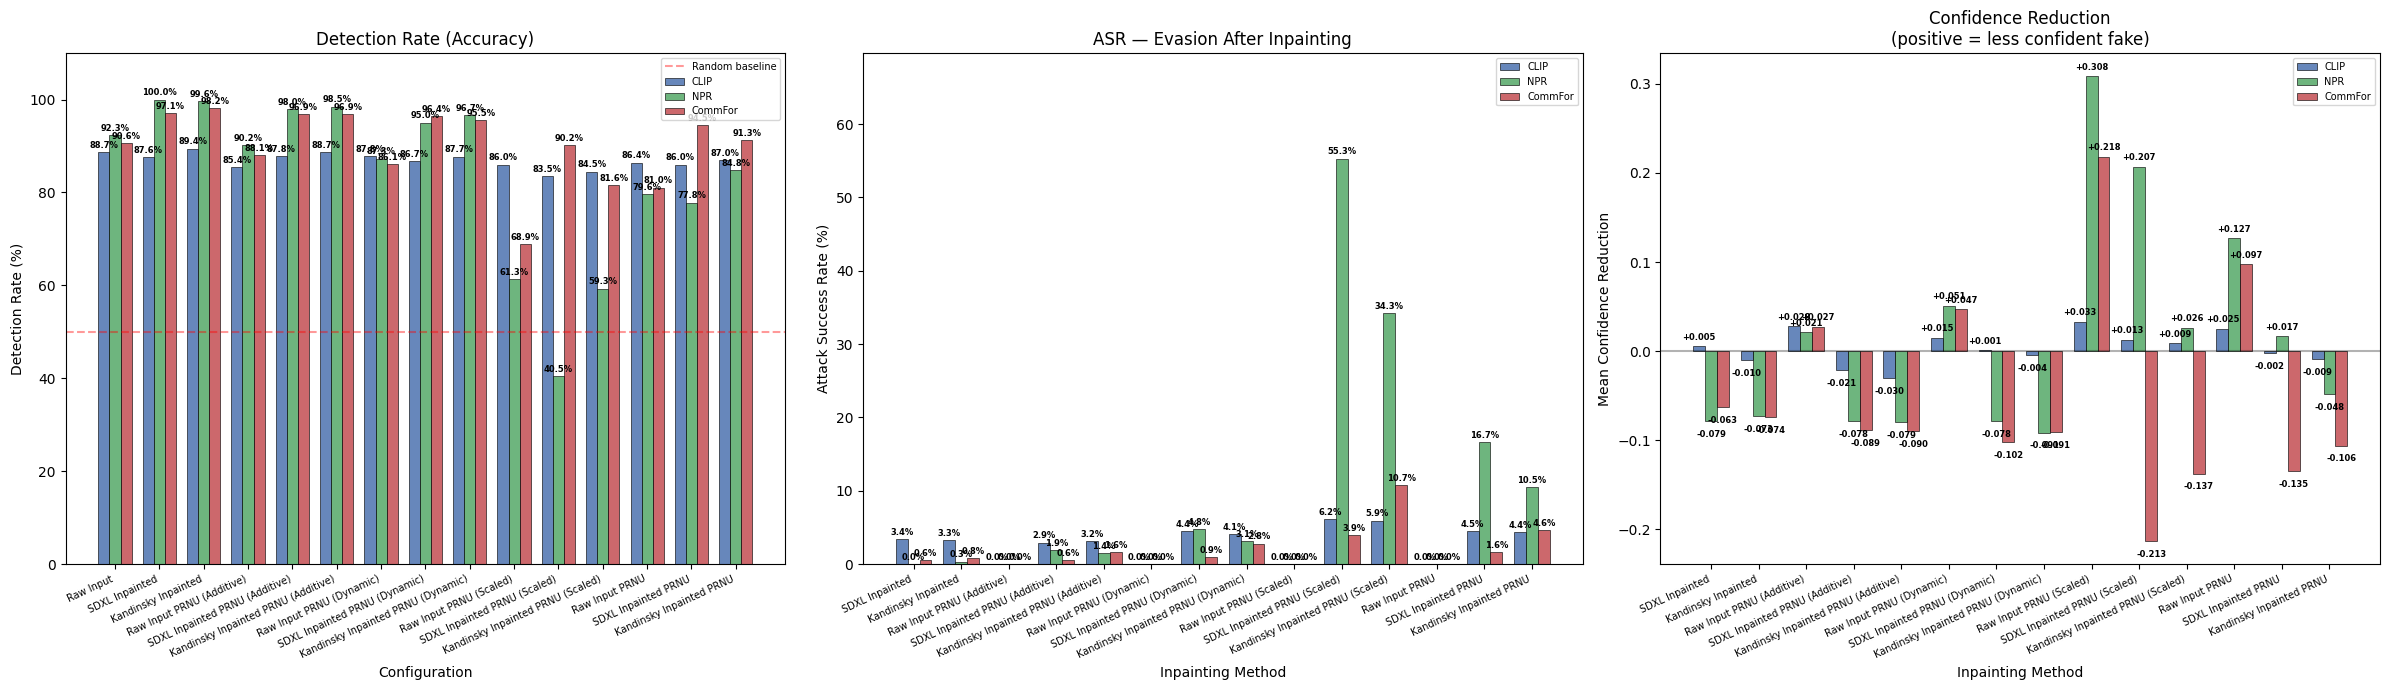

In [37]:
config_names = [c["name"] for c in CONFIGS]
model_names = list(MODELS.keys())
colors = {"CLIP": "#4C72B0", "NPR": "#55A868", "CommFor": "#C44E52"}
inpaint_configs = [c["name"] for c in CONFIGS if c.get("baseline")]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
width = 0.25

# --- Left: Detection Rate (Accuracy) per config ---
x = range(len(config_names))

for i, model_name in enumerate(model_names):
    vals = []
    for cname in config_names:
        row = [r for r in summary_rows if r["Config"] == cname and r["Model"] == model_name]
        if row and row[0]["Detection Rate"] is not None:
            vals.append(row[0]["Detection Rate"] * 100)
        else:
            vals.append(0)
    offset = (i - len(model_names) / 2 + 0.5) * width
    bars = axes[0].bar([xi + offset for xi in x], vals, width, label=model_name,
                       color=colors.get(model_name, "gray"), alpha=0.85, edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 0:
            axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                         f"{val:.1f}%", ha="center", va="bottom", fontsize=6, fontweight="bold")

axes[0].axhline(y=50, color="red", linestyle="--", alpha=0.4, label="Random baseline")
axes[0].set_xlabel("Configuration")
axes[0].set_ylabel("Detection Rate (%)")
axes[0].set_title("Detection Rate (Accuracy)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(config_names, rotation=25, ha="right", fontsize=7)
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=7)

# --- Middle: ASR per inpainting config ---
x2 = range(len(inpaint_configs))

for i, model_name in enumerate(model_names):
    vals = []
    for cname in inpaint_configs:
        row = [r for r in summary_rows if r["Config"] == cname and r["Model"] == model_name]
        if row and row[0]["ASR"] is not None:
            vals.append(row[0]["ASR"] * 100)
        else:
            vals.append(0)
    offset = (i - len(model_names) / 2 + 0.5) * width
    bars = axes[1].bar([xi + offset for xi in x2], vals, width, label=model_name,
                       color=colors.get(model_name, "gray"), alpha=0.85, edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f"{val:.1f}%", ha="center", va="bottom", fontsize=6, fontweight="bold")

axes[1].set_xlabel("Inpainting Method")
axes[1].set_ylabel("Attack Success Rate (%)")
axes[1].set_title("ASR — Evasion After Inpainting")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(inpaint_configs, rotation=25, ha="right", fontsize=7)
axes[1].set_ylim(0, max(15, axes[1].get_ylim()[1] * 1.2))
axes[1].legend(fontsize=7)

# --- Right: Mean Confidence Reduction per inpainting config ---
x3 = range(len(inpaint_configs))

for i, model_name in enumerate(model_names):
    vals = []
    for cname in inpaint_configs:
        row = [r for r in conf_reduction_rows if r["Config"] == cname and r["Model"] == model_name]
        if row:
            vals.append(row[0]["mean_reduction"])
        else:
            vals.append(0)
    offset = (i - len(model_names) / 2 + 0.5) * width
    bars = axes[2].bar([xi + offset for xi in x3], vals, width, label=model_name,
                       color=colors.get(model_name, "gray"), alpha=0.85, edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        axes[2].text(bar.get_x() + bar.get_width() / 2,
                     val + (0.005 if val >= 0 else -0.01),
                     f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top",
                     fontsize=6, fontweight="bold")

axes[2].axhline(y=0, color="black", linestyle="-", alpha=0.3)
axes[2].set_xlabel("Inpainting Method")
axes[2].set_ylabel("Mean Confidence Reduction")
axes[2].set_title("Confidence Reduction\n(positive = less confident fake)")
axes[2].set_xticks(x3)
axes[2].set_xticklabels(inpaint_configs, rotation=25, ha="right", fontsize=7)
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 11. Save Results

In [38]:
for config in CONFIGS:
    name = config["name"]
    csv_path = config["csv_path"]
    df = merged_dfs[name]

    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path} ({len(df)} rows, {len(df.columns)} columns)")

print("\nAll CSVs updated with NPR and CommFor results.")
print(f"Columns: {list(merged_dfs[CONFIGS[0]['name']].columns)}")

Saved: impainting_input.csv (1000 rows, 8 columns)
Saved: output_impainting_sdxl.csv (1000 rows, 8 columns)
Saved: output_inpainting_kandinsky.csv (1000 rows, 8 columns)
Saved: output_raw_prnu.csv (1000 rows, 8 columns)
Saved: output_impainting_sdxl_prnu.csv (1000 rows, 8 columns)
Saved: output_inpainting_kandinsky_prnu.csv (1000 rows, 8 columns)
Saved: output_raw_prnu.csv (1000 rows, 8 columns)
Saved: output_impainting_sdxl_prnu.csv (1000 rows, 8 columns)
Saved: output_inpainting_kandinsky_prnu.csv (1000 rows, 8 columns)
Saved: output_raw_prnu.csv (1000 rows, 8 columns)
Saved: output_impainting_sdxl_prnu.csv (1000 rows, 8 columns)
Saved: output_inpainting_kandinsky_prnu.csv (1000 rows, 8 columns)
Saved: output_raw_prnu.csv (3000 rows, 8 columns)
Saved: output_impainting_sdxl_prnu.csv (3000 rows, 8 columns)
Saved: output_inpainting_kandinsky_prnu.csv (3000 rows, 8 columns)

All CSVs updated with NPR and CommFor results.
Columns: ['file_name', 'path', 'CLIP_label_prediction', 'CLIP_conf